# LHS 샘플링 PDSI 계산

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
import pickle
import numpy.random as rand
import h5py
import time
from tqdm import tqdm
from pathlib import Path

In [2]:
base = Path.cwd().parents[3]
model_dir = [base / "PDSI_data" / "CA_77" / "models" / "model_1.keras", 
             base / "PDSI_data" / "CA_77" / "models" / "model_2.keras", 
             base / "PDSI_data" / "CA_77" / "models" / "model_3.keras", 
             base / "PDSI_data" / "CA_77" / "models" / "model_4.keras", 
             base / "PDSI_data" / "CA_77" / "models" / "model_5.keras"]

loaded_models = [keras.models.load_model(d) for d in model_dir]  # 모델 5개를 한 번만 로드
local_index = pd.read_csv(base / "PDSI_data" / "SDM_data" / "latin" / "local_index.csv")
local_name = local_index["SIG_ENG_NM"].tolist()

with open(base / "PDSI_data" / "SDM_data" / "latin" / "TES_maxent" / "all.pkl", 'rb') as file:
    local_all = pickle.load(file)
with open(base / "PDSI_data" / "SDM_data" / "latin" / "TES_maxent" / "sampling.pkl", 'rb') as file:
    local_lhs = pickle.load(file)
species_path = str(base / "PDSI_data" / "SDM_data" / "latin" / "TES_maxent") #분석하고 싶은 종 선택 (TES)
scenario = ['126', '126', '126', '126'] #시나리오 선택
seeed_num = 10

# 행정구역별 샘플링을 확인

In [3]:
for i, name in enumerate(local_name):
    print(f"{i}:{name}", end=" | ")

0:Goseong-gun2 | 1:Inje-gun1 | 2:Cheorwon-gun | 3:Yanggu-gun | 4:Hwacheon-gun | 5:Yeoncheon-gun | 6:Sokcho-si | 7:Pocheon-si | 8:Yangyang-gun | 9:Chuncheon-si | 10:Gapyeong-gun | 11:Paju-si | 12:Ongjin-gun | 13:Dongducheon-si | 14:Hongcheon-gun | 15:Yangju-si | 16:Gangneung-si | 17:Ganghwa-gun | 18:Pyeongchang-gun | 19:Uijeongbu-si | 20:Namyangju-si | 21:Gimpo-si | 22:Goyang-si | 23:Seoul-si | 24:Hoengseong-gun | 25:Yangpyeong-gun | 26:Guri-si | 27:Incheon-si | 28:Donghae-si | 29:Hanam-si | 30:Jeongseon-gun | 31:Bucheon-si | 32:Gwangju-si2 | 33:Ulleung-gun | 34:Wonju-si | 35:Gwangmyeong-si | 36:Siheung-si | 37:Seongnam-si | 38:Samcheok-si | 39:Gwacheon-si | 40:Anyang-si | 41:Yeoju-si | 42:Uiwang-si | 43:Yeongwol-gun | 44:Gunpo-si | 45:Ansan-si | 46:Yongin-si | 47:Icheon-si | 48:Suwon-si | 49:Taebaek-si | 50:Hwaseong-si | 51:Jecheon-si | 52:Chungju-si | 53:Osan-si | 54:Anseong-si | 55:Eumseong-gun | 56:Danyang-gun | 57:Pyeongtaek-si | 58:Uljin-gun | 59:Bonghwa-gun | 60:Yeongju-si | 61:D

Namyangju-si


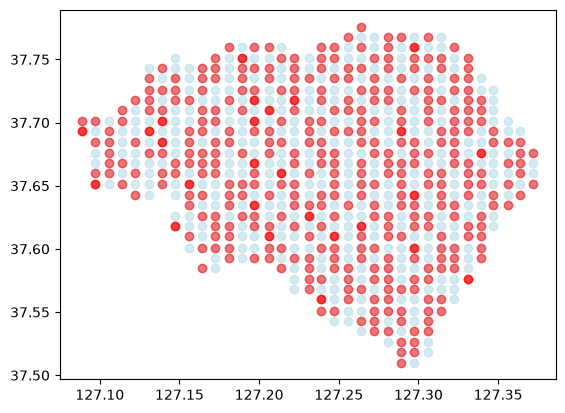

In [4]:
# 분석하고 싶은 행정구역 선택
k = 20

print(local_name[k])
aa = local_all["ssp245_2050"][local_name[k]] #시나리오, 연도에 상관 없음
bb = local_lhs["ssp245_2050"][local_name[k]]

plt.scatter(aa['x'], aa['y'], color='lightblue', label='All Data', alpha=0.5)
plt.scatter(bb['x'], bb['y'], color='red', label='All Data', alpha=0.5)

### 멕센트 데이터를 가져와 20by20의 행렬 데이터를 만드는 함수

In [5]:
#lhs
def make_maxent_mat(scenario, loc):
    maxent_mat = []
    for i in ["ssp"+str(scenario[0])+"_2030", "ssp"+str(scenario[1])+"_2050",
              "ssp"+str(scenario[2])+"_2070", "ssp"+str(scenario[3])+"_2090"]:
        dataF = local_lhs[i][loc]
        dataF = dataF.iloc[:,2]
        dataF = np.reshape(dataF,(20,20))
        maxent_mat.append(dataF)
        
    maxent_mat = np.array(maxent_mat)
    maxent_mat = np.transpose(maxent_mat,(1,2,0))
    maxent_mat = np.reshape(maxent_mat,(1,20,20,4))
    return maxent_mat

In [6]:
maxent_mat = make_maxent_mat(scenario, 'Namyangju-si')

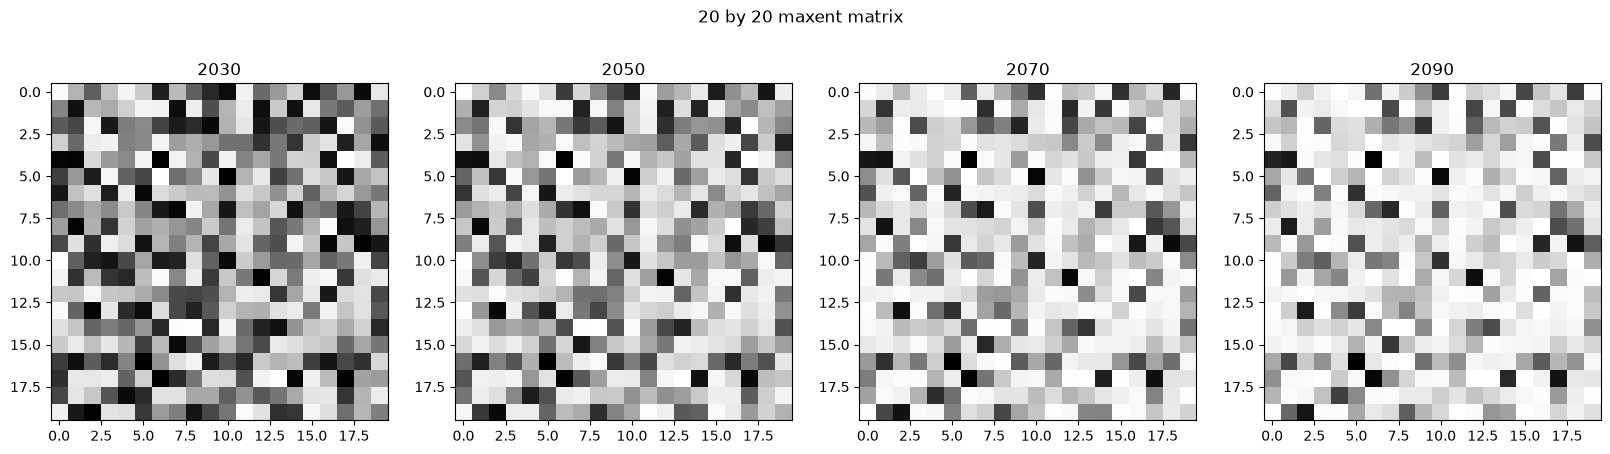

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1행 4열, 전체 그림 크기 조정

axes[0].imshow(maxent_mat[0,:,:,0], cmap="gray")
axes[0].set_title('2030')

axes[1].imshow(maxent_mat[0,:,:,1], cmap="gray")
axes[1].set_title('2050')

axes[2].imshow(maxent_mat[0,:,:,2], cmap="gray")
axes[2].set_title('2070')

axes[3].imshow(maxent_mat[0,:,:,3], cmap="gray")
axes[3].set_title('2090')

fig.suptitle("20 by 20 maxent matrix")
plt.show()

### 멕센트로 만든 20by20 행렬의 확률 값을 바이너리로 바꾸는 함수

In [8]:
# 맥센트 확률분포 바이너리화
def get_binary_maxent_mat(maxent_mat):
    a = np.random.rand(1, 20, 20, 4) # 1, 20, 20, 4 크기의 랜덤 행렬 생성
    binary_maxent_mat = (a < maxent_mat).astype(int) # maxent_mat와 비교하여 조건을 만족하는 곳에 1을 할당
    return binary_maxent_mat

### 멕센트 데이터와 바이너리화 비교

In [9]:
def binary_maxent_mat_500(maxent_mat):
    Bmm = np.zeros((1,20,20,4))
    for e in range(500):
        binary_maxent_mat = np.array(get_binary_maxent_mat(maxent_mat), dtype=np.float32) 
        Bmm += binary_maxent_mat
    Bmm = Bmm/500
    
    return Bmm

In [10]:
Bmm = binary_maxent_mat_500(maxent_mat)

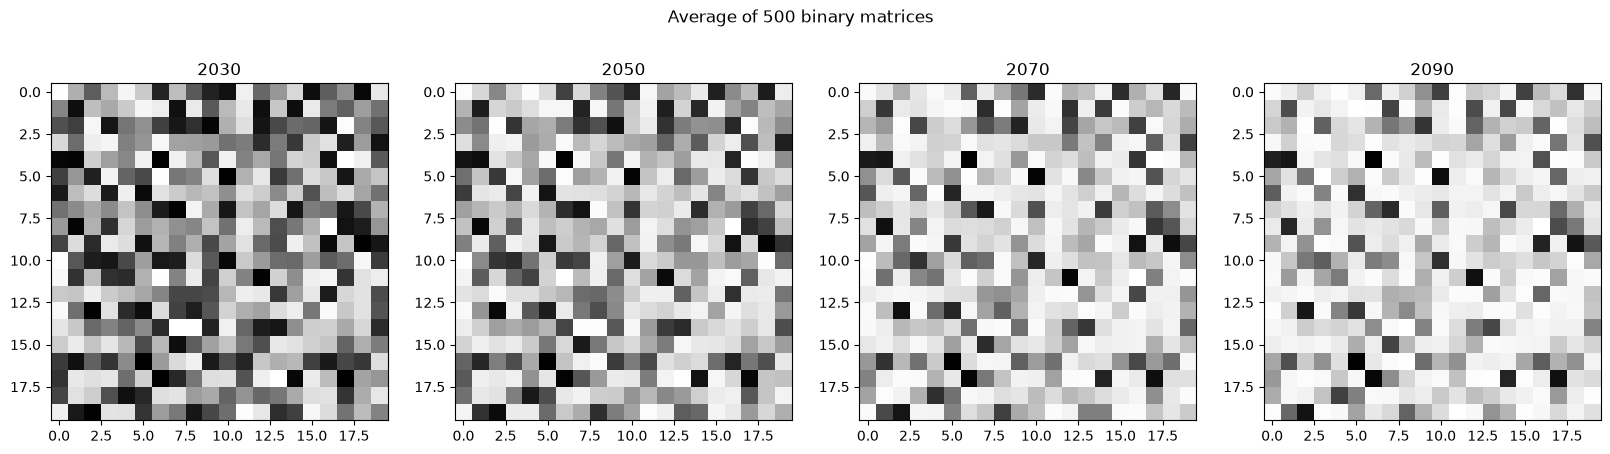

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1행 4열, 전체 그림 크기 조정

axes[0].imshow(Bmm[0,:,:,0], cmap="gray")
axes[0].set_title('2030')

axes[1].imshow(Bmm[0,:,:,1], cmap="gray")
axes[1].set_title('2050')

axes[2].imshow(Bmm[0,:,:,2], cmap="gray")
axes[2].set_title('2070')

axes[3].imshow(Bmm[0,:,:,3], cmap="gray")
axes[3].set_title('2090')

fig.suptitle("Average of 500 binary matrices")
plt.show()

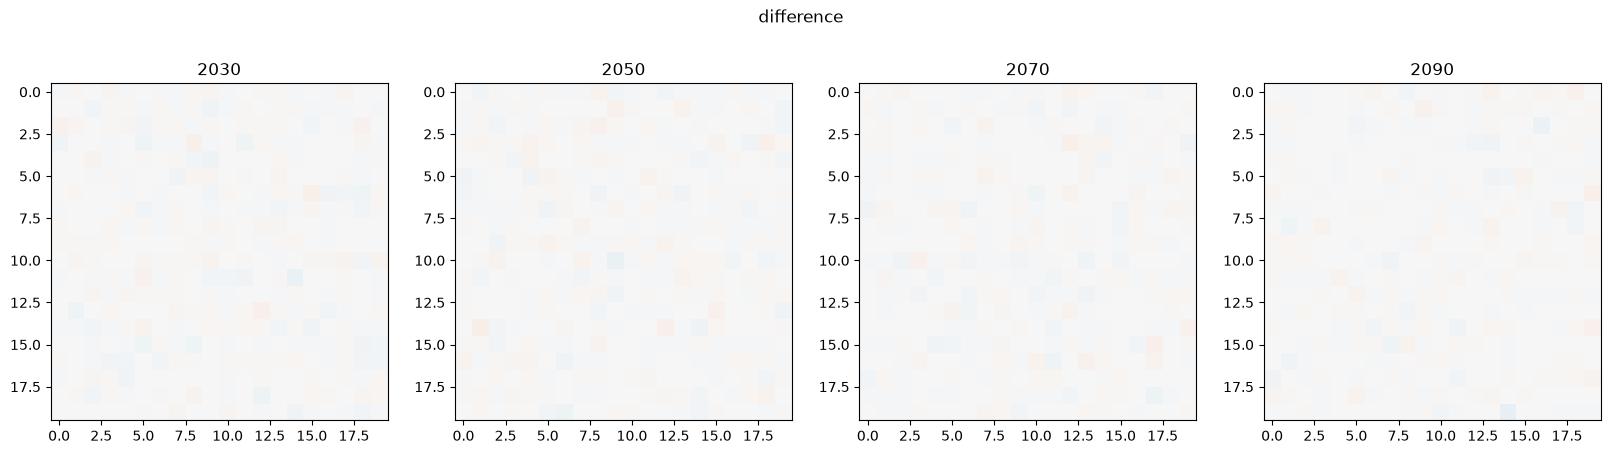

In [12]:
diff = maxent_mat - Bmm

fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1행 4열, 전체 그림 크기 조정

axes[0].imshow(diff[0,:,:,0], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title('2030')

axes[1].imshow(diff[0,:,:,1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title('2050')

axes[2].imshow(diff[0,:,:,2], cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title('2070')

axes[3].imshow(diff[0,:,:,3], cmap="RdBu_r", vmin=-1, vmax=1)
axes[3].set_title('2090')

fig.suptitle("difference")
plt.show()

### CA_distribution 구하기

In [13]:
def make_CA_distribution(maxent_mat, model):
    # distribution 구하기 (모델은 미리 로드된 loaded_models 사용, 100개씩 배치 추론)
    b = np.zeros((1, int(model)), dtype=np.float32)
    initial = 0
    # 500회 반복 시행 (모델 5개 x 배치 100)
    for model_call in loaded_models:
        binary_batch = (np.random.rand(100, 20, 20, 4) < maxent_mat).astype(np.float32)
        initial += np.sum(binary_batch[:,:,:,0])
        model_output = np.array(model_call(binary_batch), dtype=np.float32)
        b += np.sum(model_output, axis=0, keepdims=True)
    CA_distribution = b/500
    initial = int(initial/500)
    
    return initial, CA_distribution

In [14]:
initial, CA_distribution = make_CA_distribution(maxent_mat, 77)

In [15]:
labels = [8, 6, 2, 34, 38, 12, 10, 14, 26, 30, 58, 62, 74, 78, 106, 110, 40, 44, 42, 46, 136, 140, 138, 142, 154, 158, 168, 172, 170, 174, 186, 190, 130, 134, 162, 166, 234, 238, 202, 206, 24, 28, 56, 60, 152, 156, 184, 188, 4, 18, 22, 36, 50, 54, 72, 76, 90, 94, 104, 108, 122, 126, 132, 146, 150, 160, 164, 178, 182, 200, 204, 218, 222, 232, 236, 250, 254]

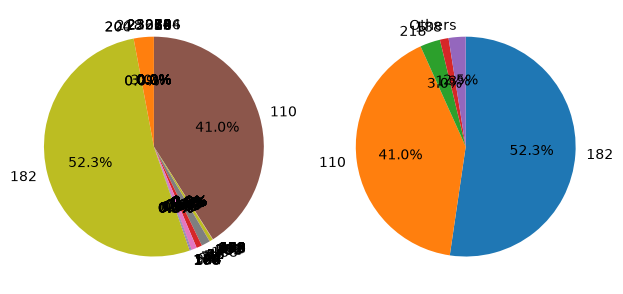

In [16]:
fig, axes = plt.subplots(1, 2) #, figsize=(12, 6))  # 1행 2열의 서브플롯 생성 (가로로 배치)

data = CA_distribution[0]

# 일반적인 원그래프
axes[0].pie(data, labels=labels ,autopct='%.1f%%', startangle=90, counterclock=False)

# 상위만 그린 원그래프
# 데이터와 레이블을 내림차순으로 정렬
sorted_indices = np.argsort(data)[::-1]
sorted_data = data[sorted_indices]
sorted_labels = np.array(labels)[sorted_indices]

# 상위 5개 항목만 선택
top_n = 4
top_data = sorted_data[:top_n]
top_labels = sorted_labels[:top_n]

# 나머지 항목을 "기타"로 처리
other_data = np.sum(sorted_data[top_n:])
other_label = 'Others'

# "기타" 항목 추가
final_data = np.append(top_data, other_data)
final_labels = np.append(top_labels, other_label)

# 파이 차트 그리기
axes[1].pie(final_data, labels=final_labels, autopct='%.1f%%', startangle=90, counterclock=False)

plt.tight_layout()  # 레이아웃 조정
plt.show()

### SI 구하기

In [17]:
weight = np.load(base / "PDSI_data" / "weights" / "WeightByInitial.npy", allow_pickle=True)

In [18]:
def clu_SI(initial, CA_distribution):
    global weight, labels
    SI = 0
    for k, i in enumerate(labels):  # k는 인덱스, i는 labels의 값
        si = CA_distribution[0][k] * weight[i][initial]  # 각 원소를 선택하여 저장
        SI += si
        
    # # 전체 면적으로 나눌 때    
    SI = SI/400
    # # 초기갑으로 나눌 때
    # if initial != 0:
    #     SI = SI / initial
    # else:
    #     SI = 0
    
    return SI

In [19]:
clu_SI(initial, CA_distribution)

np.float64(0.6642028181146533)

### 모든 시나리오 별 각 행정구역의 값 계산

In [20]:
scenarios = [['126','126','126','126'],['126','126','126','245'],['126','126','126','585'],['126','126','245','126'],['126','126','245','245'],['126','126','245','585'],['126','126','585','126'],['126','126','585','245'],['126','126','585','585'],
             ['126','245','126','126'],['126','245','126','245'],['126','245','126','585'],['126','245','245','126'],['126','245','245','245'],['126','245','245','585'],['126','245','585','126'],['126','245','585','245'],['126','245','585','585'],
             ['126','585','126','126'],['126','585','126','245'],['126','585','126','585'],['126','585','245','126'],['126','585','245','245'],['126','585','245','585'],['126','585','585','126'],['126','585','585','245'],['126','585','585','585'],
             ['245','126','126','126'],['245','126','126','245'],['245','126','126','585'],['245','126','245','126'],['245','126','245','245'],['245','126','245','585'],['245','126','585','126'],['245','126','585','245'],['245','126','585','585'],
             ['245','245','126','126'],['245','245','126','245'],['245','245','126','585'],['245','245','245','126'],['245','245','245','245'],['245','245','245','585'],['245','245','585','126'],['245','245','585','245'],['245','245','585','585'],
             ['245','585','126','126'],['245','585','126','245'],['245','585','126','585'],['245','585','245','126'],['245','585','245','245'],['245','585','245','585'],['245','585','585','126'],['245','585','585','245'],['245','585','585','585'],
             ['585','126','126','126'],['585','126','126','245'],['585','126','126','585'],['585','126','245','126'],['585','126','245','245'],['585','126','245','585'],['585','126','585','126'],['585','126','585','245'],['585','126','585','585'],
             ['585','245','126','126'],['585','245','126','245'],['585','245','126','585'],['585','245','245','126'],['585','245','245','245'],['585','245','245','585'],['585','245','585','126'],['585','245','585','245'],['585','245','585','585'],
             ['585','585','126','126'],['585','585','126','245'],['585','585','126','585'],['585','585','245','126'],['585','585','245','245'],['585','585','245','585'],['585','585','585','126'],['585','585','585','245'],['585','585','585','585']]

In [21]:
# 시나리오별 처리 함수 정의
def process_scenario(scenario, base, local_name):
    # 파일을 추가 모드로 열기
    with h5py.File(base / "PDSI_data" / "Results" / "77_lhs.h5", 'a') as f:
        scenario_name = str(scenario[0])+'_'+str(scenario[1])+'_'+str(scenario[2])+'_'+str(scenario[3])
        # 이미 처리된 시나리오인지 확인
        if scenario_name in f:
            print(f"시나리오 {scenario_name}은 이미 처리되었습니다. 건너뜁니다.")
            return
        # 새 시나리오 그룹 생성
        scenario_group = f.create_group(f'{scenario_name}')
        # 이 시나리오의 모든 지역 처리
        for loc in local_name:
            maxent_mat = make_maxent_mat(scenario, loc)
            initial, CA_distribution = make_CA_distribution(maxent_mat, 77)
            SI = clu_SI(initial, CA_distribution)
            # 각 행정구역별 하위그룹 생성
            loc_group = scenario_group.create_group(f'{loc}')
            loc_group.create_dataset('initial', data=initial)
            loc_group.create_dataset('CA_distribution', data=CA_distribution)
            loc_group.create_dataset('SI', data=SI)
        print(f"시나리오 {scenario_name} 완료 및 저장됨")

In [22]:
# 파일이 없으면 새로 생성
import os
if not os.path.exists(base / "PDSI_data" / "Results" / "77_lhs.h5"):
    with h5py.File(str(base / "PDSI_data" / "Results" / "77_lhs.h5"), 'w') as f:
        pass  # 빈 파일 생성|
# 모든 시나리오 처리
for scenario in tqdm(scenarios, desc="전체 시나리오 처리 중"):
    process_scenario(scenario, base, local_name)

전체 시나리오 처리 중:   0%|          | 0/81 [00:00<?, ?it/s]

시나리오 126_126_126_126은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_126_245은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_126_585은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_245_126은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_245_245은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_245_585은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_585_126은 이미 처리되었습니다. 건너뜁니다.
시나리오 126_126_585_245은 이미 처리되었습니다. 건너뜁니다.


전체 시나리오 처리 중:  11%|█         | 9/81 [00:09<01:14,  1.04s/it]

시나리오 126_126_585_585 완료 및 저장됨


전체 시나리오 처리 중:  12%|█▏        | 10/81 [00:18<02:34,  2.17s/it]

...

전체 시나리오 처리 중:  99%|█████████▉| 80/81 [11:11<00:09,  9.23s/it]

시나리오 585_585_585_245 완료 및 저장됨


전체 시나리오 처리 중: 100%|██████████| 81/81 [11:20<00:00,  9.19s/it]

전체 시나리오 처리 중: 100%|██████████| 81/81 [11:20<00:00,  8.40s/it]

시나리오 585_585_585_585 완료 및 저장됨


In [23]:
# 데이터가 잘 만들어서 저장되어 있는지 확인합니다.
with h5py.File(str(base / "PDSI_data" / "Results" / "77_lhs.h5"), 'r') as f:
    # 그룹에 접근
    inje_group = f['585_585_585_585']['Inje-gun1']
    # 각 데이터셋 접근
    ca_distribution = inje_group['CA_distribution'][()]
    si_data = inje_group['SI'][()]
    initial_data = inje_group['initial'][()]
    
    # 데이터 확인
    print("CA_distribution 데이터:", ca_distribution.shape)
    print(ca_distribution)
    print("\nSI 데이터:")
    print(si_data)
    print("\ninitial 데이터:")
    print(initial_data)

CA_distribution 데이터: (1, 77)
[[4.01551461e-06 4.98974914e-05 1.08158906e-06 2.68598285e-07
  4.42292709e-08 2.66348332e-04 5.59252726e-07 1.04760496e-04
  1.14826580e-04 1.45233003e-03 7.08926564e-06 2.16076810e-08
  3.20397895e-08 2.99707845e-05 4.14877571e-03 2.99746262e-05
  2.16266335e-06 9.39001562e-04 8.08910201e-08 2.60613753e-08
  1.08306494e-06 5.54651087e-05 4.07240009e-07 2.22539074e-05
  8.16835742e-03 8.49498072e-09 3.20560116e-06 4.66439487e-05
  5.84487134e-06 2.62971434e-06 2.39084839e-05 3.07267219e-05
  1.15174669e-06 7.19353993e-05 1.07694696e-07 2.22839822e-06
  5.30189194e-04 4.01748503e-06 2.93257320e-03 4.86318413e-06
  2.26519798e-04 4.00525551e-07 1.24431326e-05 4.63155098e-02
  6.03899753e-05 5.83252267e-06 2.52218124e-05 1.49380043e-07
  2.60451912e-07 1.50046423e-01 2.58584023e-01 3.84886043e-05
  3.11736153e-06 3.94429779e-03 3.17213335e-07 1.32144603e-04
  4.87910777e-01 6.69429573e-05 2.73244259e-05 1.27269332e-05
  3.32310738e-04 2.50048324e-05 7.4453978

In [24]:
#SI 데이터만 추출하여 저장합니다.
with h5py.File(str(base / "PDSI_data" / "Results" / "77_lhs.h5"), 'r') as f:
    # 최상위 키(시나리오 목록) 가져오기
    scenarios = list(f.keys())
    locs = list(f[scenarios[0]].keys())
    df = pd.DataFrame(index=locs, columns=scenarios)
    for scenario in scenarios:
        for loc in locs:
            df.loc[loc, scenario] = f[scenario][loc]['SI'][()]
df.to_csv(str(base / "PDSI_data" / "Results" / "77_lhs.csv"))